<a href="https://colab.research.google.com/github/NavameyPJ/Multi-Asset-Portfolio-Optimization-VaR/blob/main/Multi_Asset_Portfolio_Optimization_VaR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  5 of 5 completed

Fetching historical market data...

=== PHASE 1: ASSET RISK & RETURN SUMMARY ===


              Annualized Return  Annualized Volatility  Daily Return Std Dev
Ticker                                                                      
HDFCBANK.NS              0.0836                 0.2575                0.0162
ICICIBANK.NS             0.1612                 0.2989                0.0188
INFY.NS                  0.1596                 0.2740                0.0173
RELIANCE.NS              0.1399                 0.2822                0.0178
TCS.NS                   0.0909                 0.2376                0.0150


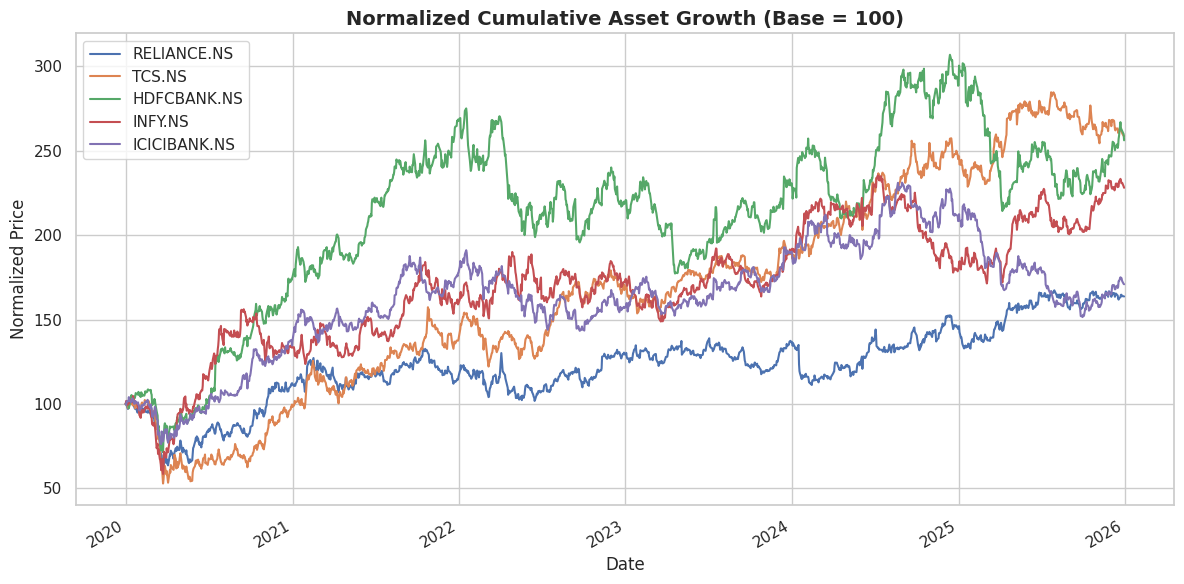

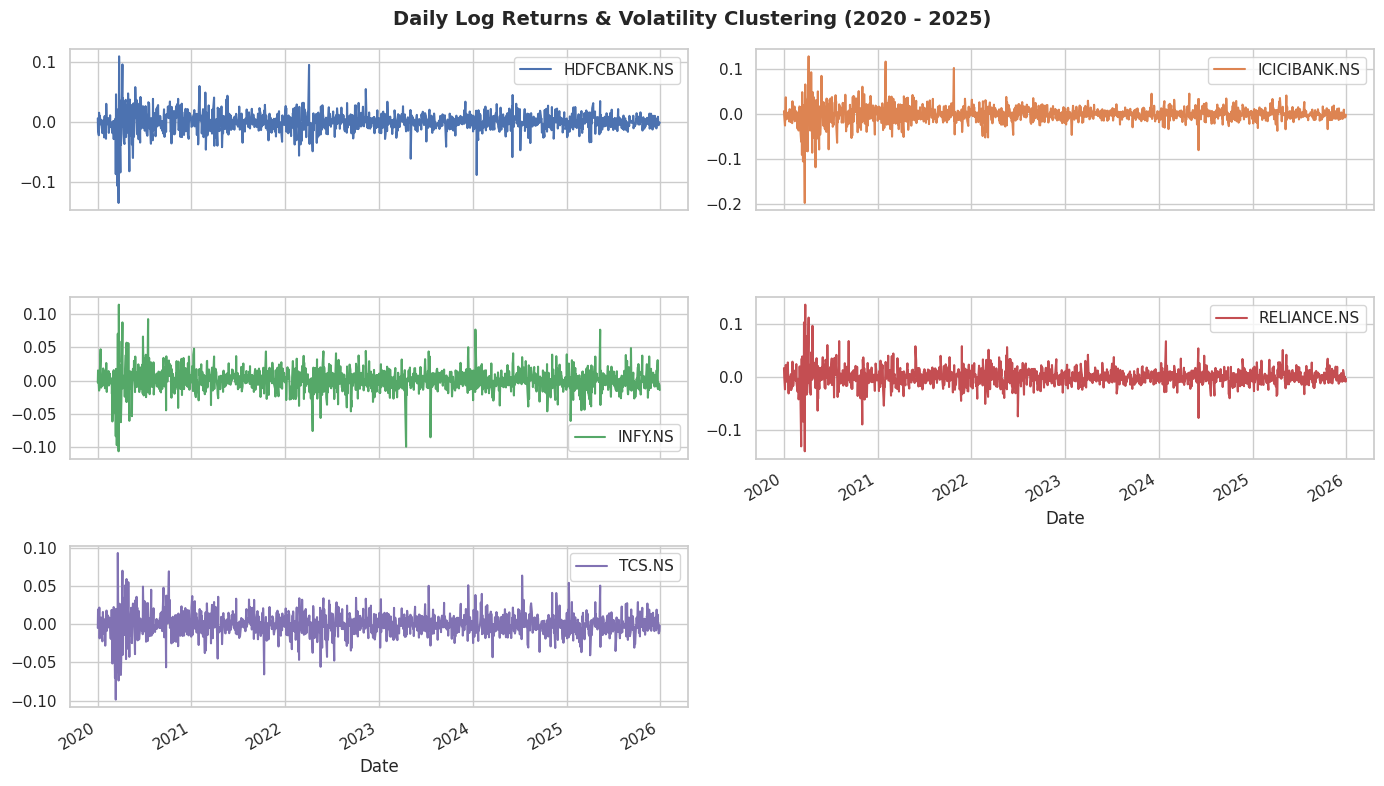

In [2]:
# 1. Install financial data library
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual aesthetic
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 2. Define Portfolio Tickers (Top 5 Blue-Chip Equities)
tickers = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'ICICIBANK.NS']
start_date = '2020-01-01'
end_date = '2025-12-31'

print("Fetching historical market data...")
# Set auto_adjust=False explicitly to preserve 'Adj Close'
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)['Adj Close']

# 3. Handle missing trading days
data = data.ffill().dropna()

# 4. Calculate Daily Logarithmic Returns
log_returns = np.log(data / data.shift(1)).dropna()

# 5. Compute Annualized Risk and Return Metrics (252 Trading Days)
mean_daily_returns = log_returns.mean()
annualized_returns = mean_daily_returns * 252

daily_volatility = log_returns.std()
annualized_volatility = daily_volatility * np.sqrt(252)

# Summary DataFrame
summary_table = pd.DataFrame({
    'Annualized Return': annualized_returns,
    'Annualized Volatility': annualized_volatility,
    'Daily Return Std Dev': daily_volatility
})

print("\n=== PHASE 1: ASSET RISK & RETURN SUMMARY ===")
print(summary_table.round(4))

# 6. Plot Normalized Price Performance
normalized_prices = (data / data.iloc[0]) * 100
normalized_prices.plot()
plt.title('Normalized Cumulative Asset Growth (Base = 100)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend(tickers)
plt.tight_layout()
plt.show()

# 7. Plot Log Returns to observe Volatility Clustering
log_returns.plot(subplots=True, layout=(3, 2), figsize=(14, 8), sharex=True)
plt.suptitle('Daily Log Returns & Volatility Clustering (2020 - 2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== PHASE 2: OPTIMAL PORTFOLIO WEIGHT ALLOCATIONS ===
             Max Sharpe Portfolio Min Variance Portfolio
RELIANCE.NS                  0.0%                 30.49%
TCS.NS                     34.14%                  5.58%
HDFCBANK.NS                47.15%                  6.02%
INFY.NS                    18.72%                 16.44%
ICICIBANK.NS                 0.0%                 41.46%

=== PORTFOLIO PERFORMANCE METRICS ===
Max Sharpe Portfolio  -> Return: 15.65%, Volatility: 22.17%, Sharpe: 0.4125
Min Variance Portfolio -> Return: 10.48%, Volatility: 19.34%, Sharpe: 0.2057


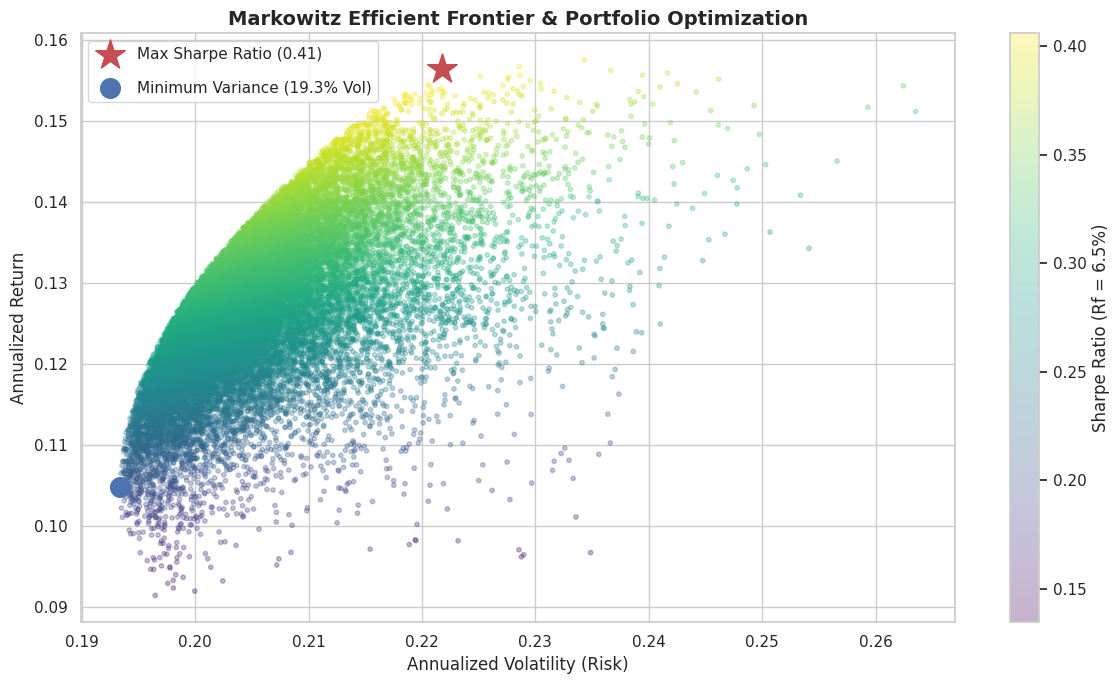

In [3]:
import scipy.optimize as sco

# 1. Benchmark Parameters
rf_rate = 0.065  # 6.5% Risk-Free Rate (RBI 10-Year G-Sec Yield)
num_assets = len(tickers)
cov_matrix = log_returns.cov() * 252  # Annualized Covariance Matrix

# 2. Helper Functions for Portfolio Analytics
def portfolio_performance(weights):
    ret = np.sum(weights * annualized_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = (ret - rf_rate) / vol
    return ret, vol, sharpe

def min_func_sharpe(weights):
    return -portfolio_performance(weights)[2]  # Negative Sharpe for minimization

def min_func_volatility(weights):
    return portfolio_performance(weights)[1]   # Minimize Volatility

# 3. Monte Carlo Simulation (25,000 Random Portfolios)
num_portfolios = 25000
results = np.zeros((3 + num_assets, num_portfolios))

np.random.seed(42)
for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)

    p_ret, p_vol, p_sharpe = portfolio_performance(weights)
    results[0, i] = p_ret
    results[1, i] = p_vol
    results[2, i] = p_sharpe
    for j in range(num_assets):
        results[3 + j, i] = weights[j]

# 4. Exact Numerical Optimization using Scipy
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))
init_guess = num_assets * [1.0 / num_assets,]

# Max Sharpe Ratio Optimization
opt_sharpe = sco.minimize(min_func_sharpe, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
max_sr_weights = opt_sharpe.x
max_sr_ret, max_sr_vol, max_sr_ratio = portfolio_performance(max_sr_weights)

# Min Variance Optimization
opt_vol = sco.minimize(min_func_volatility, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
min_vol_weights = opt_vol.x
min_vol_ret, min_vol_vol, min_vol_ratio = portfolio_performance(min_vol_weights)

# 5. Display Optimal Allocation Tables
opt_weights_df = pd.DataFrame({
    'Max Sharpe Portfolio': max_sr_weights,
    'Min Variance Portfolio': min_vol_weights
}, index=tickers)

print("=== PHASE 2: OPTIMAL PORTFOLIO WEIGHT ALLOCATIONS ===")
print((opt_weights_df * 100).round(2).astype(str) + '%')

print("\n=== PORTFOLIO PERFORMANCE METRICS ===")
print(f"Max Sharpe Portfolio  -> Return: {max_sr_ret*100:.2f}%, Volatility: {max_sr_vol*100:.2f}%, Sharpe: {max_sr_ratio:.4f}")
print(f"Min Variance Portfolio -> Return: {min_vol_ret*100:.2f}%, Volatility: {min_vol_vol*100:.2f}%, Sharpe: {min_vol_ratio:.4f}")

# 6. Plot Markowitz Efficient Frontier
plt.figure(figsize=(12, 7))
plt.scatter(results[1, :], results[0, :], c=results[2, :], cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio (Rf = 6.5%)')

# Highlight Optimal Portfolios
plt.scatter(max_sr_vol, max_sr_ret, marker='*', color='r', s=500, label=f'Max Sharpe Ratio ({max_sr_ratio:.2f})')
plt.scatter(min_vol_vol, min_vol_ret, marker='o', color='b', s=200, label=f'Minimum Variance ({min_vol_vol*100:.1f}% Vol)')

plt.title('Markowitz Efficient Frontier & Portfolio Optimization', fontsize=14, fontweight='bold')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Return')
plt.legend(labelspacing=1.2)
plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 7.6 MB/s eta 0:00:00
=== GARCH(1,1) MODEL PARAMETERS ===
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0771  2.946e-02      2.617  8.879e-03 [1.935e-02,  0.135]

=== PHASE 3: PORTFOLIO MARKET RISK ENGINE ($10M PORTFOLIO) ===
                        1-Day 99% VaR (%)  1-Day 99% VaR ($)  \
Historical Simulation                4.24          423535.12   
Parametric (GARCH)                   2.13          212808.73   
Monte Carlo Simulation               2.12          212262.21   

                        1-Day 99% Expected Shortfall ($)  
Historical Simulation                          628286.61  
Parametric (GARCH)                             244711.81  
Monte Carlo Simulation                         247689.22  


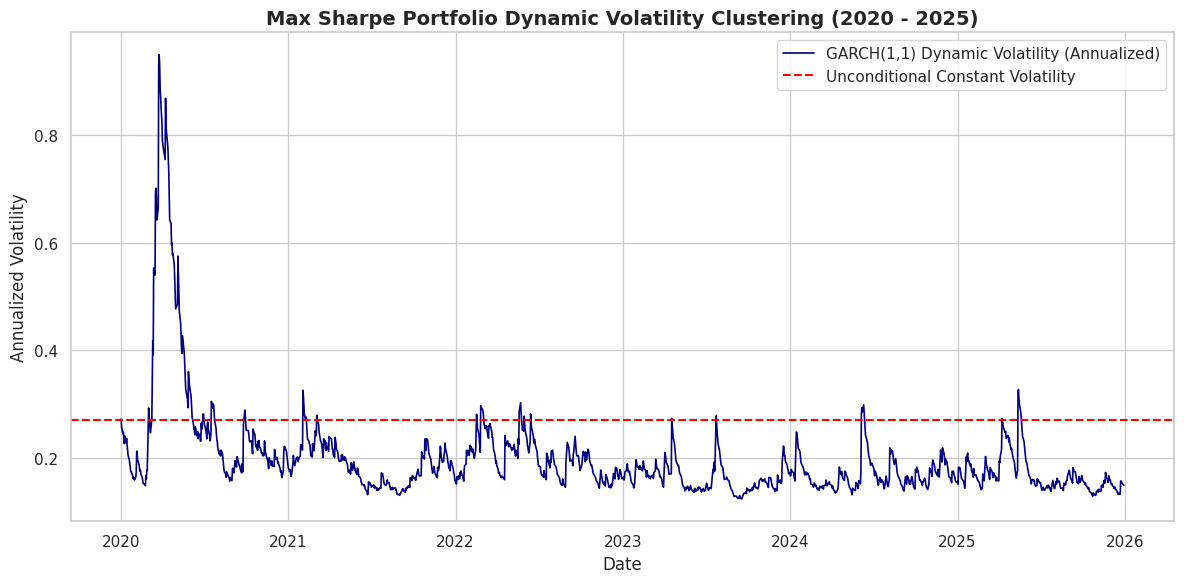

In [4]:
# 1. Install ARCH package for dynamic volatility modeling
!pip install arch -q

import numpy as np
import pandas as pd
from arch import arch_model
import scipy.stats as stats
import matplotlib.pyplot as plt

# 2. Compute Daily Max Sharpe Portfolio Log Returns
portfolio_daily_returns = log_returns.dot(max_sr_weights)

# 3. Fit GARCH(1,1) Volatility Model
garch = arch_model(portfolio_daily_returns * 100, vol='Garch', p=1, q=1, dist='Normal')
garch_fit = garch.fit(disp='off')

# Extract conditional annualized daily volatility
conditional_vol = (garch_fit.conditional_volatility / 100)

# 4. Define Market Risk Parameters
portfolio_val = 10000000  # $10 Million Portfolio Baseline
confidence_level = 0.99
alpha_quantile = 1 - confidence_level

# --- Method A: Historical Simulation VaR & CVaR ---
var_hist_pct = -np.percentile(portfolio_daily_returns, alpha_quantile * 100)
cvar_hist_pct = -portfolio_daily_returns[portfolio_daily_returns <= -var_hist_pct].mean()

# --- Method B: Parametric GARCH(1,1) VaR & CVaR ---
current_garch_vol = conditional_vol.iloc[-1]
z_score = stats.norm.ppf(confidence_level)
var_param_pct = z_score * current_garch_vol - portfolio_daily_returns.mean()
cvar_param_pct = (stats.norm.pdf(z_score) / alpha_quantile) * current_garch_vol - portfolio_daily_returns.mean()

# --- Method C: Monte Carlo Simulation (10,000 Price Paths) ---
np.random.seed(42)
n_simulations = 10000
mc_sim_returns = np.random.normal(portfolio_daily_returns.mean(), current_garch_vol, n_simulations)
var_mc_pct = -np.percentile(mc_sim_returns, alpha_quantile * 100)
cvar_mc_pct = -mc_sim_returns[mc_sim_returns <= -var_mc_pct].mean()

# 5. Construct Risk Engine Summary Table
risk_summary = pd.DataFrame({
    '1-Day 99% VaR (%)': [var_hist_pct * 100, var_param_pct * 100, var_mc_pct * 100],
    '1-Day 99% VaR ($)': [var_hist_pct * portfolio_val, var_param_pct * portfolio_val, var_mc_pct * portfolio_val],
    '1-Day 99% Expected Shortfall ($)': [cvar_hist_pct * portfolio_val, cvar_param_pct * portfolio_val, cvar_mc_pct * portfolio_val]
}, index=['Historical Simulation', 'Parametric (GARCH)', 'Monte Carlo Simulation'])

print("=== GARCH(1,1) MODEL PARAMETERS ===")
print(garch_fit.summary().tables[1])

print("\n=== PHASE 3: PORTFOLIO MARKET RISK ENGINE ($10M PORTFOLIO) ===")
print(risk_summary.round(2))

# 6. Plot GARCH Dynamic Volatility vs Constant Volatility
plt.figure(figsize=(12, 6))
plt.plot(conditional_vol * np.sqrt(252), label='GARCH(1,1) Dynamic Volatility (Annualized)', color='navy', lw=1.2)
plt.axhline(annualized_volatility.mean(), color='red', linestyle='--', label='Unconditional Constant Volatility')
plt.title('Max Sharpe Portfolio Dynamic Volatility Clustering (2020 - 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.legend()
plt.tight_layout()
plt.show()